# MDCS eval code (ver 1.0)

## Import Necessary libraries

In [1]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas
import csv

## Custom MST Functions

In [13]:
def read_header(BaseFolder,Date,Run):
    with open(BaseFolder + Date + '/' + 'Run' + Run + '/' + 'MDCS' + Run + '_Header.txt', "r", encoding="utf8") as data_file:
        reader = csv.reader(data_file, delimiter="\t")
        header_data = list(reader)
        
    data_dict = {}
    data_dict['Emission Energy'] = np.array(header_data[1]).astype(float)
    data_dict['Stepped Energy'] = np.array(header_data[2]).astype(float)
    data_dict['Population Steps'] = np.array(header_data[3]).astype(float)
    
    for i in range(0,len(header_data[4])):
        try:
            data_dict[header_data[4][i]] = float(header_data[5][i])
        except:
            data_dict[header_data[4][i]] = header_data[5][i]
        
    data_dict['Scan Notes'] = header_data[6][1]
     
    return data_dict

def read_data(BaseFolder,Date,Run,header_data):

    Spec2D = np.zeros((len(header_data['Population Steps']),len(header_data['Stepped Energy']),len(header_data['Emission Energy'])),dtype=complex)

    for i in range(0,len(header_data['Population Steps'])):
        Spec_amp = pandas.read_csv(BaseFolder + Date + '/' + 'Run' + Run + '/' + 'MDCS' + Run + '_2DSpec_amp_T' + str(i) + '.tsv',sep='\t',header=None)
        Spec_phase = pandas.read_csv(BaseFolder + Date + '/' + 'Run' + Run + '/' + 'MDCS' + Run + '_2DSpec_phase_T' + str(i) + '.tsv',sep='\t',header=None)

        Spec2D[i] = (Spec_amp*np.exp(1j*Spec_phase)).transpose()
        
    return Spec2D

def plot_data(header_data,spectrum,min_val,max_val,plot_type='Abs',sizex=5,sizey=5):
    
    if plot_type =='Real':
        plt.set_cmap("seismic")
        data_plot = np.real(spectrum)
        label = "Real part"
        line_color = 'black'
    else:
        plt.set_cmap("magma")
        data_plot = abs(spectrum)
        label = "Magnitude"
        line_color = 'white'
        
    fig, (ax) = plt.subplots(1, figsize=(sizex, sizey))
    im = ax.imshow(data_plot,extent=[header_data['Emission Energy'][0],header_data['Emission Energy'][len(header_data['Emission Energy'])-1],
                                                header_data['Stepped Energy'][len(header_data['Stepped Energy'])-1],header_data['Stepped Energy'][0]],
                                                vmin=min_val,vmax=max_val)
    
    if header_data['Scan type'] == '1Q-R' or header_data['Scan type'] == '1Q':
        step_size = abs(header_data['Stepped Energy'][1]-header_data['Stepped Energy'][0])
        ax.plot([1000, 2500],[-1000, -2500],linestyle='dashed',color=line_color)
        ax.set_ylim([-header_data['Plot range max (units)'],-header_data['Plot range min (units)']-step_size])
        ax.set_ylabel('Absorption Energy (' + header_data['Energy units'] + ')', fontweight ='bold')
        ax.set_xlim([header_data['Plot range min (units)']+step_size,header_data['Plot range max (units)']])   
        
    elif header_data['Scan type'] == '1Q-NR':
        ax.plot([1000, 2500],[1000, 2500],linestyle='dashed',color=line_color)
        ax.set_ylim([header_data['Plot range min (units)'],header_data['Plot range max (units)']])
        ax.set_ylabel('Absorption Energy (' + header_data['Energy units'] + ')', fontweight ='bold')
        ax.set_xlim([header_data['Plot range min (units)'],header_data['Plot range max (units)']])   
        
    elif header_data['Scan type'] == '0Q':
        ax.set_ylim([header_data['Stepped Energy'][0],header_data['Stepped Energy'][len(header_data['Stepped Energy'])-1]])
        ax.set_ylabel('Mixing Energy (' + header_data['Energy units'] + ')', fontweight ='bold')
        ax.set_xlim([header_data['Plot range min (units)'],header_data['Plot range max (units)']])  
        
    elif header_data['Scan type'] == '2Q':
        ax.plot([1000, 2500],[2000, 5000],linestyle='dashed',color=line_color)
        ax.set_ylim([header_data['Stepped Energy'][0],header_data['Stepped Energy'][len(header_data['Stepped Energy'])-1]])
        ax.set_ylabel('Double-Quantum Energy (' + header_data['Energy units'] + ')', fontweight ='bold')
        ax.set_xlim([header_data['Plot range min (units)'],header_data['Plot range max (units)']])  
    
     
    ax.set_xlabel('Emission Energy (' + header_data['Energy units'] + ')', fontweight ='bold')  
    ax.set_aspect('equal', adjustable='box', anchor='C')
    plt.colorbar(im,label=label, orientation="vertical",fraction=0.046, pad=0.04)
    
    return fig

mpl.rcParams["font.family"] = "Arial"
mpl.rcParams["axes.labelsize"] = "16"
mpl.rcParams["axes.titlesize"] = "16"
mpl.rcParams["xtick.labelsize"] = "16"
mpl.rcParams["ytick.labelsize"] = "16"

## Import & Plot Data

<Figure size 640x480 with 0 Axes>

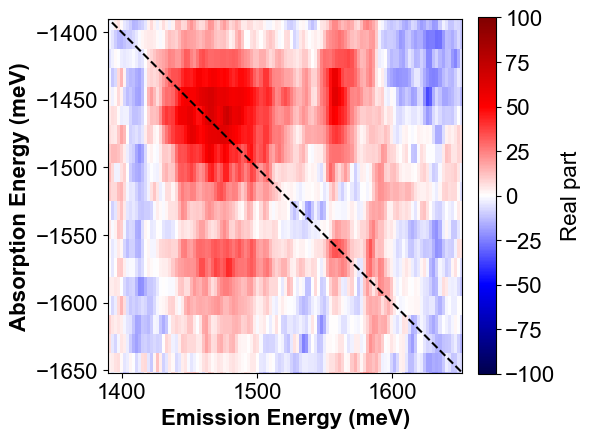

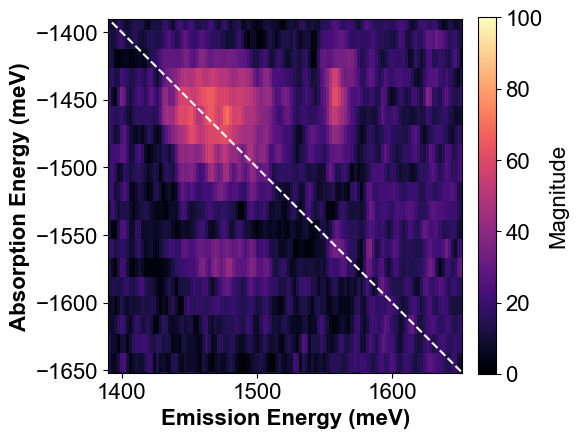

In [27]:
BaseFolder = 'C:/Users/purz/Downloads/'
Date = '2025-02-20'
Run = '003'

header_data = read_header(BaseFolder,Date,Run)
spectrum = read_data(BaseFolder,Date,Run,header_data)
fig1 = plot_data(header_data,spectrum[0],min_val=-100,max_val=100,plot_type='Real',sizex=5,sizey=5)
fig2 = plot_data(header_data,spectrum[0],min_val=0,max_val=100,plot_type='Abs',sizex=5,sizey=5)